<a href="https://colab.research.google.com/github/C026-01-0774-2023-NewtonOlando/Machine-learning/blob/main/clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import (
    KMeans,
    DBSCAN,
    AgglomerativeClustering
)

from sklearn.decomposition import PCA

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

In [3]:
df = pd.read_csv(
    "/content/drive/MyDrive/cloud_performance_features.csv"
)

print(df.shape)

df.head()

(2000000, 15)


,cpu_usage,memory_usage,network_traffic,power_consumption,num_executed_instructions,execution_time,energy_efficiency,task_type,task_priority,task_status,year,month,day,hour,day_of_week
0,54.881350,78.950861,164.775973,287.808986,7527.0,69.345575,0.553589,2,2,2,2023.0,1.0,25.0,9.0,2.0
1,71.518937,29.901883,500.007595,362.273569,5348.0,41.396040,0.349856,1,0,0,2023.0,1.0,26.0,4.0,3.0
2,50.054758,92.709195,203.674847,231.467903,5483.0,24.602549,0.796277,1,2,0,2023.0,1.0,13.0,23.0,4.0
3,54.488318,88.100960,500.007595,195.639954,5876.0,16.456670,0.529511,0,0,0,2023.0,2.0,9.0,11.0,3.0
4,42.365480,49.976089,500.007595,359.451537,3361.0,55.307992,0.351907,1,2,2,2023.0,6.0,14.0,8.0,2.0


In [4]:
print(df.isnull().sum())

print(
    "Total Missing Values:",
    df.isnull().sum().sum()
)

cpu_usage                         0
memory_usage                      0
network_traffic                   0
power_consumption                 0
num_executed_instructions         0
execution_time                    0
energy_efficiency                 0
task_type                         0
task_priority                     0
task_status                       0
year                         200666
month                        200666
day                          200666
hour                         200666
day_of_week                  200666
dtype: int64
Total Missing Values: 1003330


In [5]:
date_columns = ["year", "month", "day", "hour", "day_of_week"]

for col in date_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)
    df[col] = df[col].astype(int)

In [6]:
print(df.isnull().sum())
print("Total Missing Values:", df.isnull().sum().sum())

cpu_usage                    0
memory_usage                 0
network_traffic              0
power_consumption            0
num_executed_instructions    0
execution_time               0
energy_efficiency            0
task_type                    0
task_priority                0
task_status                  0
year                         0
month                        0
day                          0
hour                         0
day_of_week                  0
dtype: int64
Total Missing Values: 0


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [8]:

df_sample = df.sample(n=50000, random_state=42)

print(df_sample.shape)

(50000, 15)


In [9]:
X = df.copy()

print(X.shape)
X.head()

(2000000, 15)


,cpu_usage,memory_usage,network_traffic,power_consumption,num_executed_instructions,execution_time,energy_efficiency,task_type,task_priority,task_status,year,month,day,hour,day_of_week
0,54.881350,78.950861,164.775973,287.808986,7527.0,69.345575,0.553589,2,2,2,2023,1,25,9,2
1,71.518937,29.901883,500.007595,362.273569,5348.0,41.396040,0.349856,1,0,0,2023,1,26,4,3
2,50.054758,92.709195,203.674847,231.467903,5483.0,24.602549,0.796277,1,2,0,2023,1,13,23,4
3,54.488318,88.100960,500.007595,195.639954,5876.0,16.456670,0.529511,0,0,0,2023,2,9,11,3
4,42.365480,49.976089,500.007595,359.451537,3361.0,55.307992,0.351907,1,2,2,2023,6,14,8,2


In [10]:
X = df_sample.copy()

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(50000, 15)


In [11]:
wcss = []

K = range(2, 11)

for k in K:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

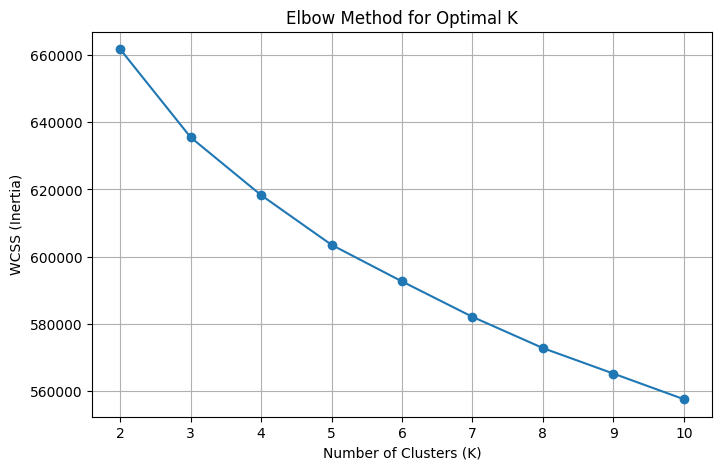

In [12]:
plt.figure(figsize=(8,5))

plt.plot(K, wcss, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method for Optimal K")

plt.grid(True)

plt.show()

In [13]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

print("Clusters:", np.unique(kmeans_labels))

Clusters: [0 1 2 3]


In [14]:
silhouette = silhouette_score(X_scaled, kmeans_labels)

davies = davies_bouldin_score(X_scaled, kmeans_labels)

calinski = calinski_harabasz_score(X_scaled, kmeans_labels)

print("K-Means Evaluation")
print("------------------")
print(f"Silhouette Score        : {silhouette:.4f}")
print(f"Davies-Bouldin Index    : {davies:.4f}")
print(f"Calinski-Harabasz Index : {calinski:.4f}")

K-Means Evaluation
------------------
Silhouette Score        : 0.0484
Davies-Bouldin Index    : 3.4567
Calinski-Harabasz Index : 2202.3959


In [15]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(50000, 2)


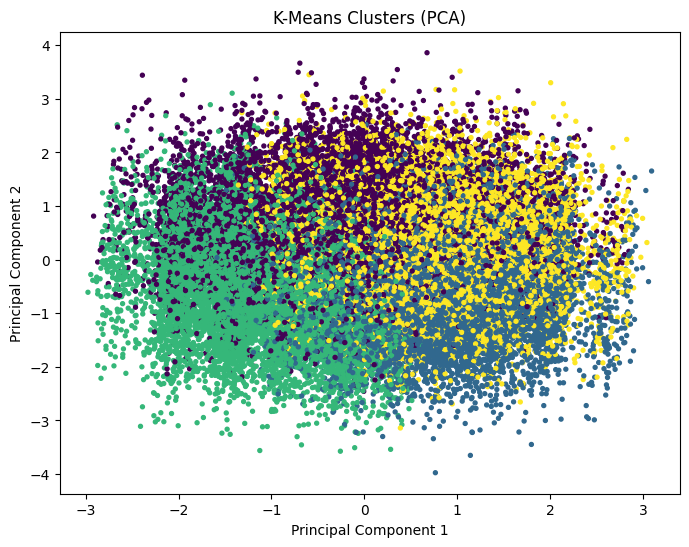

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmeans_labels,
    cmap="viridis",
    s=8
)

plt.title("K-Means Clusters (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [17]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=10
)

dbscan_labels = dbscan.fit_predict(X_scaled)

print(np.unique(dbscan_labels))

[-1  0  1  2  3  4  5  6]


In [18]:

mask = dbscan_labels != -1

if len(np.unique(dbscan_labels[mask])) > 1:

    sil = silhouette_score(
        X_scaled[mask],
        dbscan_labels[mask]
    )

    db = davies_bouldin_score(
        X_scaled[mask],
        dbscan_labels[mask]
    )

    ch = calinski_harabasz_score(
        X_scaled[mask],
        dbscan_labels[mask]
    )

    print("DBSCAN Evaluation")
    print("-----------------")
    print(f"Silhouette Score        : {sil:.4f}")
    print(f"Davies-Bouldin Index    : {db:.4f}")
    print(f"Calinski-Harabasz Index : {ch:.4f}")

else:
    print("DBSCAN did not find enough clusters.")

DBSCAN Evaluation
-----------------
Silhouette Score        : 0.2965
Davies-Bouldin Index    : 1.1179
Calinski-Harabasz Index : 28.2181


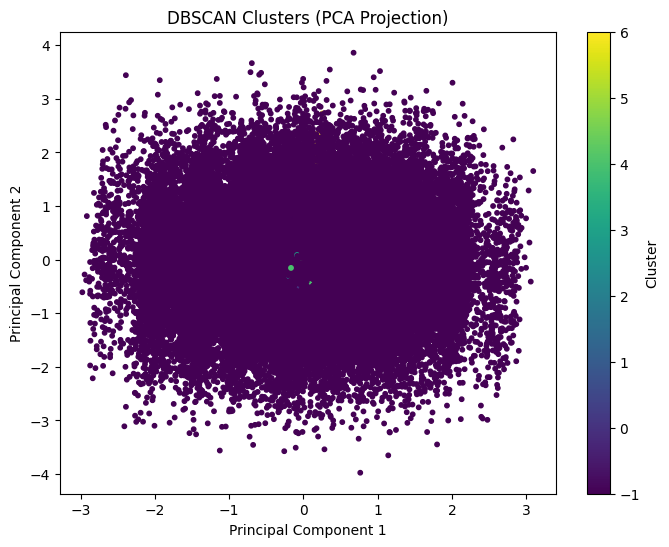

In [19]:
# PCA visualization for DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels,
    cmap="viridis",
    s=10
)

plt.colorbar(scatter, label="Cluster")
plt.title("DBSCAN Clusters (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [20]:
from sklearn.cluster import AgglomerativeClustering

In [ ]:
agg_model = AgglomerativeClustering(
    n_clusters=4
)

agg_labels = agg_model.fit_predict(X_scaled)